<a href="https://colab.research.google.com/github/qaiserzulfiqar4/student-performance-prediction/blob/main/student_performance_analysis_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:

np.random.seed (42)

student = 200
study_hours = np.random.uniform(1,10, student)
attendance = np.random.uniform(50,100, student)
previous_marks = np.random.uniform(40,90, student)
assignments = np.random.randint(2,11, student)
sleep_hours = np.random.uniform(4,9, student)

final_marks = (
    0.8*study_hours
    +0.25*attendance
    +0.35*previous_marks
    +1.2*assignments
    +1.5*sleep_hours
    +np.random.normal(0,5,student)
)
final_marks = np.clip(final_marks, 40, 100,)
df= pd.DataFrame({
     "Study_hours" : study_hours.round(2),
     "Attendance" :attendance.round(2),
     "Previous_Marks" : previous_marks.round(2),
     "Assignments" : assignments,
     "SleepHours": sleep_hours.round(2),
     "FinalMarks": final_marks.round(2),
     })
df.head()

,Study_hours,Attendance,Previous_Marks,Assignments,SleepHours,FinalMarks
0,4.37,82.10,45.16,6,8.11,69.59
1,9.56,54.21,85.13,3,4.55,59.90
2,7.59,58.08,65.26,7,8.23,64.66
3,6.39,94.93,81.32,6,4.64,72.36
4,2.40,80.32,56.00,7,5.99,62.02


In [ ]:
df.to_csv("student_data.csv", index=False)
print("student_data.csv created succesfully!")

student_data.csv created succesfully!


In [ ]:
print("First 5 Student:")
display(df.head())

First 5 Student:


,Study_hours,Attendance,Previous_Marks,Assignments,SleepHours,FinalMarks
0,4.37,82.10,45.16,6,8.11,69.59
1,9.56,54.21,85.13,3,4.55,59.90
2,7.59,58.08,65.26,7,8.23,64.66
3,6.39,94.93,81.32,6,4.64,72.36
4,2.40,80.32,56.00,7,5.99,62.02


In [ ]:
print ("Last 5 Student:")
display(df.tail())

Last 5 Student:


,Study_hours,Attendance,Previous_Marks,Assignments,SleepHours,FinalMarks
195,4.14,96.54,63.70,7,5.44,65.16
196,7.53,92.92,73.38,3,5.78,71.96
197,9.07,71.45,48.62,6,7.60,59.02
198,8.98,87.54,49.61,2,5.49,59.59
199,8.02,87.73,42.04,7,6.83,61.57


In [ ]:

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_hours     200 non-null    float64
 1   Attendance      200 non-null    float64
 2   Previous_Marks  200 non-null    float64
 3   Assignments     200 non-null    int64  
 4   SleepHours      200 non-null    float64
 5   FinalMarks      200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


In [ ]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Study_hours,Attendance,Previous_Marks,Assignments,SleepHours,FinalMarks
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,5.356250,75.218450,66.034100,6.010000,6.36045,62.754050
std,2.653884,14.649697,15.365594,2.596848,1.43253,8.791271
min,1.050000,50.250000,40.540000,2.000000,4.02000,43.000000
25%,3.057500,63.072500,52.775000,4.000000,5.04750,56.895000
50%,5.450000,77.080000,66.270000,6.000000,6.26000,62.705000
75%,7.812500,87.110000,80.557500,8.000000,7.55000,68.180000
max,9.880000,99.530000,89.990000,10.000000,8.98000,85.140000


In [ ]:
print("Missing Values:")
print(df.isnull().sum)

Missing Values:
<bound method DataFrame.sum of      Study_hours  Attendance  Previous_Marks  Assignments  SleepHours  \
0          False       False           False        False       False   
1          False       False           False        False       False   
2          False       False           False        False       False   
3          False       False           False        False       False   
4          False       False           False        False       False   
..           ...         ...             ...          ...         ...   
195        False       False           False        False       False   
196        False       False           False        False       False   
197        False       False           False        False       False   
198        False       False           False        False       False   
199        False       False           False        False       False   

     FinalMarks  
0         False  
1         False  
2         False  
3   

In [ ]:
df = df.drop_duplicates()
print("Data clening completed!")
print("Total rows:",len(df))

Data clening completed!
Total rows: 200


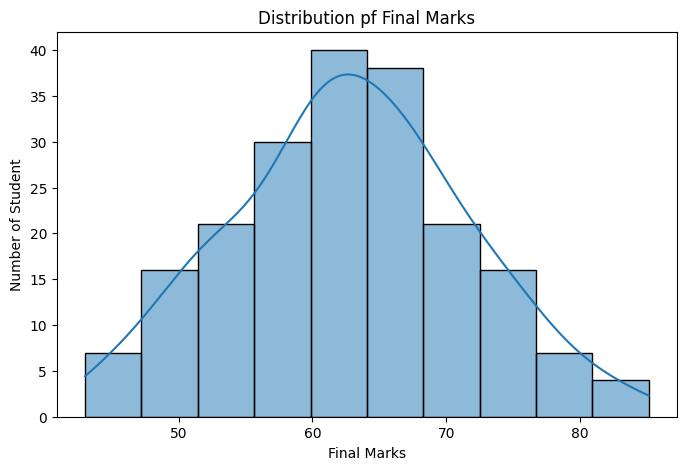

In [ ]:
plt.figure (figsize=(8,5))

sns.histplot(df["FinalMarks"],bins=10, kde=True)

plt.title("Distribution pf Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Student")
plt.show()

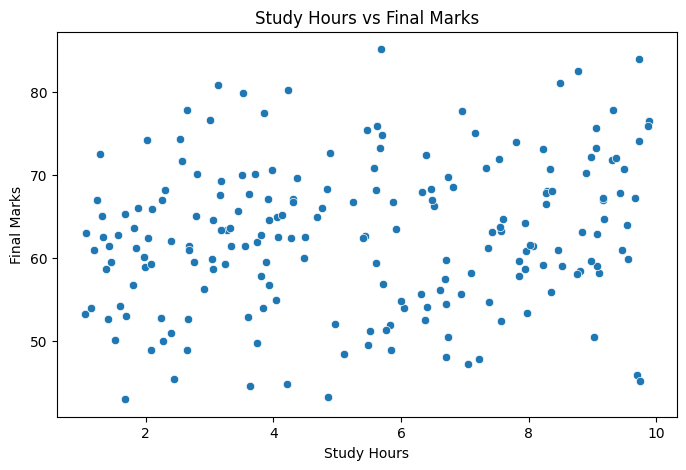

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Study_hours",
    y="FinalMarks"
)
plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

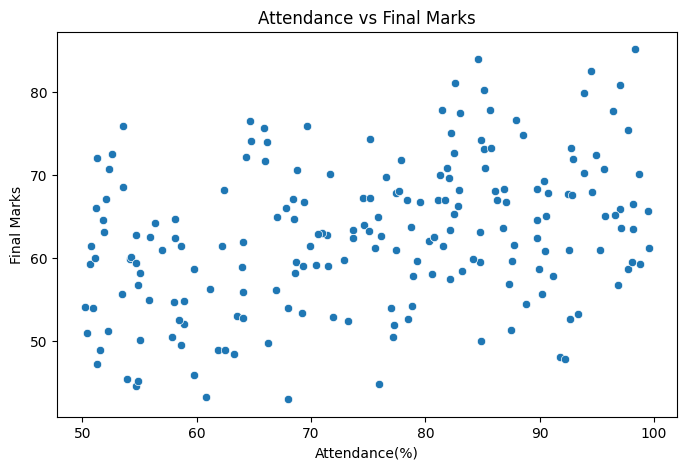

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="FinalMarks"
)
plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance(%)")
plt.ylabel("Final Marks")
plt.show()

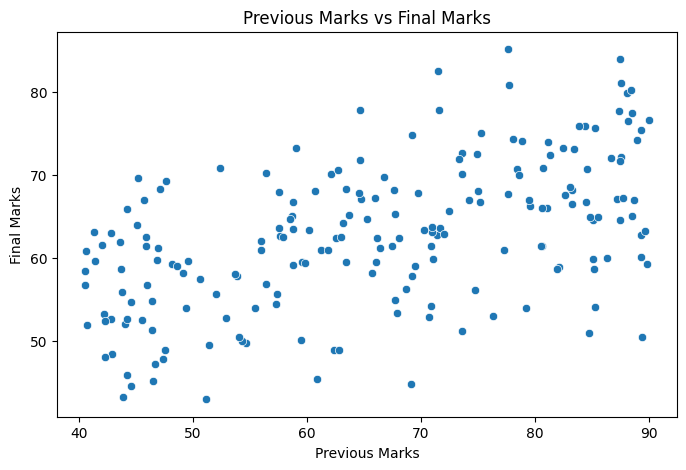

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(
data=df,
x="Previous_Marks",
y="FinalMarks"
)
plt.title("Previous Marks vs Final Marks")
plt.xlabel("Previous Marks")
plt.ylabel("Final Marks")
plt.show()

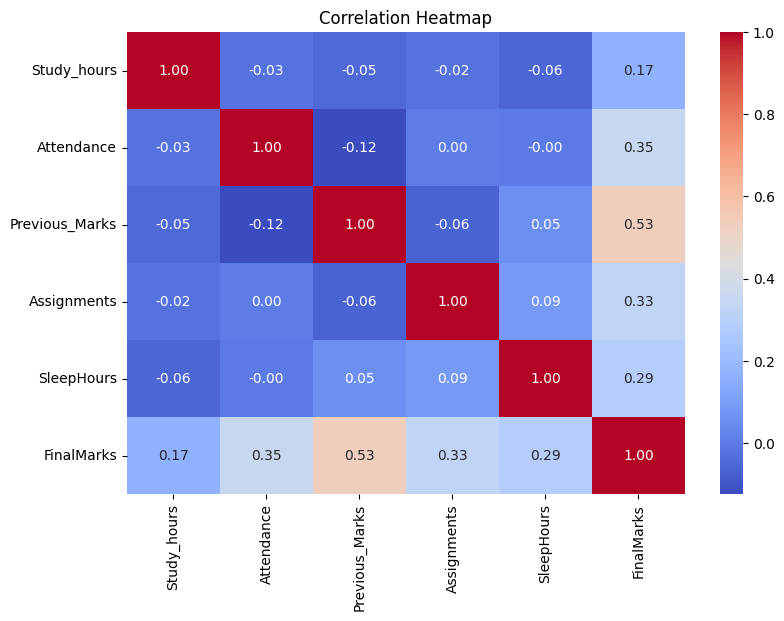

In [102]:
plt.figure(figsize=(9,6))
correlation = df.corr(numeric_only=True)
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
x=df[
   [ "Study_hours",
    "Attendance",
    "Previous_Marks"]
]
y = df["FinalMarks"]
print("Features:")
print("Target:")

Features:
Target:


In [ ]:
X_train, X_test, y_train, y_test= train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("Traning data:",X_train.shape)
print("Testing data:",X_test.shape)

Traning data: (160, 3)
Testing data: (40, 3)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
Y_pred = model.predict(X_test)
print("First 10 prediction")
print(Y_pred[:10])

First 10 prediction
[59.76997988 56.24288043 60.06831382 70.74413984 50.66409608 58.16630213
 70.29457822 58.31252992 63.92673817 76.23483899]


In [ ]:
comparison = pd.DataFrame({
"Actual Marks":y_test.values,"Predicted Marks": Y_pred.round(2)
})
display(comparison.head(10))

,Actual Marks,Predicted Marks
0,62.62,59.77
1,48.96,56.24
2,68.26,60.07
3,80.89,70.74
4,62.97,50.66
5,63.09,58.17
6,76.45,70.29
7,58.19,58.31
8,68.61,63.93
9,77.68,76.23


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
import numpy as np
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("R2 Score:", round(r2,3))
print("MSE:", round(mse,3))
print("RMSE:", round(rmse,3))

R2 Score: 0.452
MSE: 42.322
RMSE: 6.506


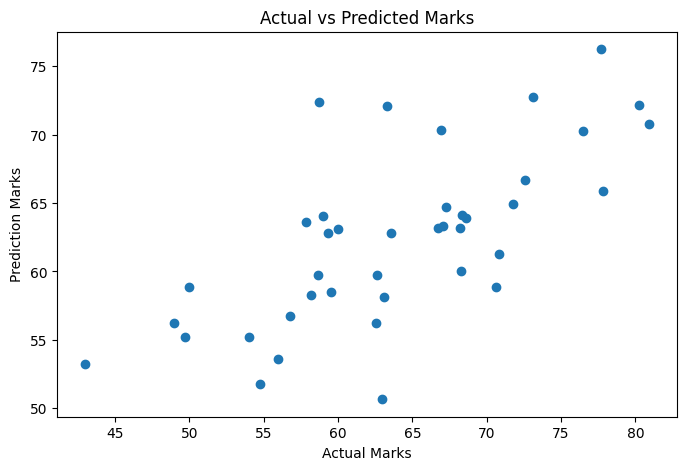

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Prediction Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

In [ ]:
import pandas as pd
new_student=pd.DataFrame(
[[6,85,75]],
 columns=["Study_hours", "Attendance", "Previous_Marks"])
prediction = model.predict(new_student)
print("Predicted Final Marks:",
      round(prediction[0],2))

Predicted Final Marks: 68.45


In [ ]:
coefficients = pd.DataFrame({
    "Features":x.columns,
    "Coefficients":model.coef_
})
display(coefficients)

,Features,Coefficients
0,Study_hours,0.588048
1,Attendance,0.250158
2,Previous_Marks,0.353328


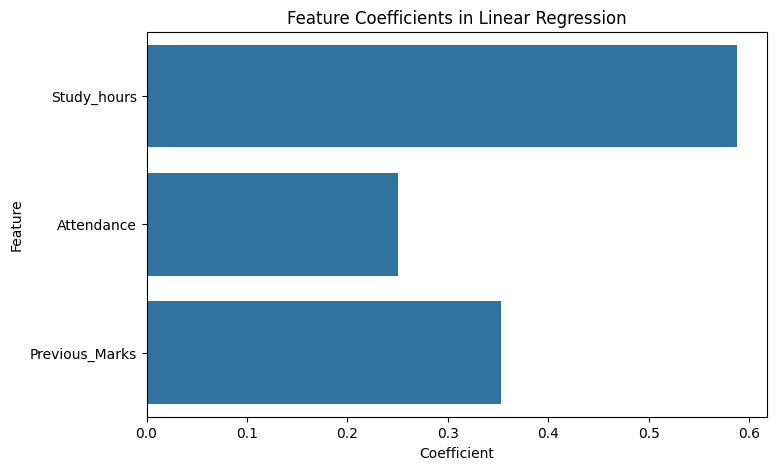

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=coefficients,
    x="Coefficients",
    y="Features"
)
plt.title("Feature Coefficients in Linear Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [ ]:
print("Student Performance Project")
print("Data Size:",df.shape)
print("/nFeatures Used:")
for column in x.columns:
  print("_", column)
  print("/nTarget Variable:")
  print("- FinalMarks")
  print("/n Model:")
  print("-Linear Regression:")
  print("/nModel Performane:")
  print("r2 Score:" ,round(r2,3))
  print("MSE:",round(mse,3))
  print("RMSE:",round(rmse,3))
  print("/nProjet completed successfully!")

Student Performance Project
Data Size: (200, 6)
/nFeatures Used:
_ Study_hours
/nTarget Variable:
- FinalMarks
/n Model:
-Linear Regression:
/nModel Performane:
r2 Score: 0.452
MSE: 42.322
RMSE: 6.506
/nProjet completed successfully!
_ Attendance
/nTarget Variable:
- FinalMarks
/n Model:
-Linear Regression:
/nModel Performane:
r2 Score: 0.452
MSE: 42.322
RMSE: 6.506
/nProjet completed successfully!
_ Previous_Marks
/nTarget Variable:
- FinalMarks
/n Model:
-Linear Regression:
/nModel Performane:
r2 Score: 0.452
MSE: 42.322
RMSE: 6.506
/nProjet completed successfully!
